**Credit Risk Modelling**

import libaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns

read data

In [2]:
df = pd.read_csv("BankChurners.csv") #convert csv file to readable datafram

In [3]:
#first five columns of data
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


Identify Null Values in data

In [4]:
if df.isnull().any(axis=1).sum() == 0:
    print("No null values")
else:
    print(df[df.isnull().any(axis=1)])

No null values


Data transformation

In [5]:
#since CLIENTNUM is just an identifier, we will that column as our index
df = df.set_index(df["CLIENTNUM"])
df = df.drop(columns=["CLIENTNUM"])


In [6]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
CLIENTNUM,,,,,,,,,,,,,,,,,,,,,
768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [7]:
#The last two columns will not be used as they are displaying the probability of a customer being an existing customer or attrited customer
df = df.iloc[:, :-2]

Identify outliers or odd values (error in data entry)

In [8]:
cols = df.select_dtypes(include=["int64","float64"]).columns

col1 = []
col2 = []
for x in range(0,len(cols)//2):
    col1.append(cols[x])
for y in range(len(cols)//2, len(cols)):
    col2.append(cols[y])

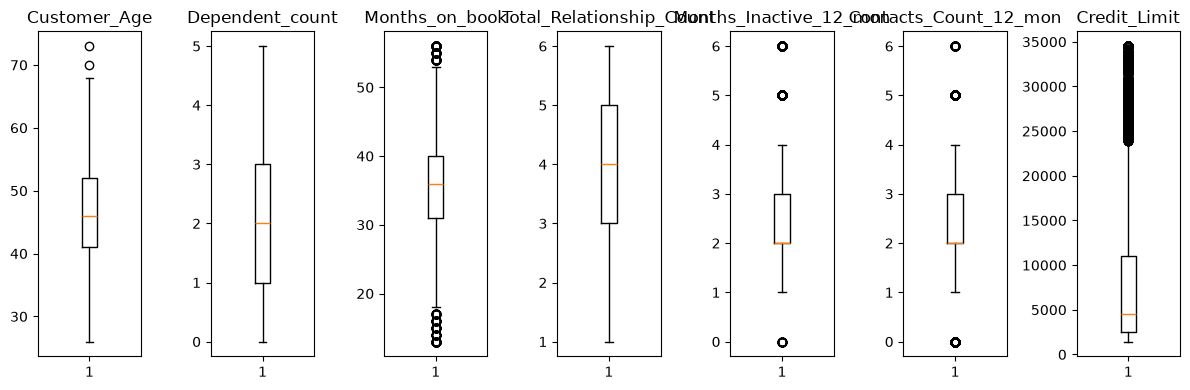

In [9]:

fig, axes = plt.subplots(1, len(col1), figsize=(12, 4))
for ax, c in zip(axes, col1):
    ax.boxplot(df[c])
    ax.set_title(c)
plt.tight_layout()
plt.show()

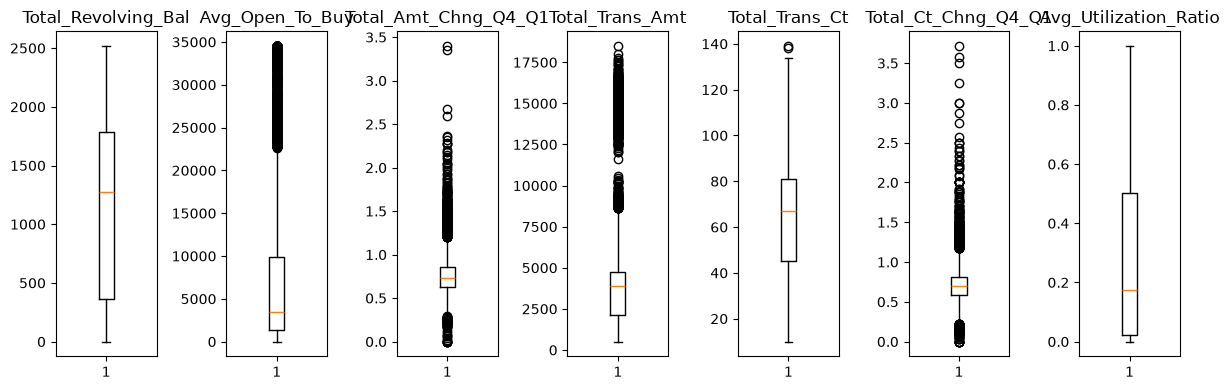

In [10]:
fig, axes = plt.subplots(1, len(col2), figsize=(12, 4))
for ax, c in zip(axes, col2):
    ax.boxplot(df[c])
    ax.set_title(c)
plt.tight_layout()
plt.show()

Since there isnt negative values or values that might be impossible we'll assume there is no error in data entry

**Turn all data types to numeric**

In [11]:
columns = df.select_dtypes(include="object").columns
for x in columns:
    print(f"{x}:{df[x].unique()}")

Attrition_Flag:['Existing Customer' 'Attrited Customer']
Gender:['M' 'F']
Education_Level:['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
Marital_Status:['Married' 'Single' 'Unknown' 'Divorced']
Income_Category:['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']
Card_Category:['Blue' 'Gold' 'Silver' 'Platinum']


In [12]:
#We cannot use get_dummies in this scenario as there would be too much columns for a proper EDA
#Given that I have planned to use Random Forest Classifier to predict the final outcome, we will label each value as numeric values e.g (0 - 10), it would also be appropriate since we are
#able to see a clear ordinal value 

df["Attrition_Flag"] = df["Attrition_Flag"].map({'Existing Customer':0, 'Attrited Customer':1})
df["Gender"] = df["Gender"].map({'M':1, 'F':0})

mappings = {

    "Education_Level" : {
        "Unknown":0,
        "Uneducated":1,
        "High School":2,
        "College":3,
        "Graduate":4,
        "Post-Graduate":5,
        "Doctorate":6
    },

    "Marital_Status" : {
        "Unknown":0,
        "Single":1,
        "Married":2,
        "Divorced":3
    },

    "Income_Category" : {
        "Unknown":0,
        'Less than $40K':1,
        "$40K - $60K":2,
        "$60K - $80K":3,
        "$80K - $120K":4,
        "$120K +":5
    },

    "Card_Category":
    {
        "Blue":0,
        "Silver":1,
        "Gold":2,
        "Platinum":3
    }
}


for col, mapping in mappings.items():
    df[col] = df[col].map(mapping)


In [13]:
for x in df.columns:
    print(x,df[x].max())

Attrition_Flag 1
Customer_Age 73
Gender 1
Dependent_count 5
Education_Level 6
Marital_Status 3
Income_Category 5
Card_Category 3
Months_on_book 56
Total_Relationship_Count 6
Months_Inactive_12_mon 6
Contacts_Count_12_mon 6
Credit_Limit 34516.0
Total_Revolving_Bal 2517
Avg_Open_To_Buy 34516.0
Total_Amt_Chng_Q4_Q1 3.397
Total_Trans_Amt 18484
Total_Trans_Ct 139
Total_Ct_Chng_Q4_Q1 3.714
Avg_Utilization_Ratio 0.999


In [14]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
CLIENTNUM,,,,,,,,,,,,,,,,,,,,
768805383,0,45,1,3,2,2,3,0,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
818770008,0,49,0,5,4,1,1,0,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
713982108,0,51,1,3,4,2,4,0,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
769911858,0,40,0,4,2,0,1,0,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
709106358,0,40,1,3,1,2,3,0,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [15]:
#Final Check
df.dtypes

Attrition_Flag                int64
Customer_Age                  int64
Gender                        int64
Dependent_count               int64
Education_Level               int64
Marital_Status                int64
Income_Category               int64
Card_Category                 int64
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object

In [16]:
#let

**EDA**

pearson value and r value

In [17]:
target = 'Attrition_Flag'
for col in df.columns:
    if col == target:
        continue
    r, p = pearsonr(df[col],df[target])
    print(f"{col:25s} r={r:+.3f} p={p:.4f}")

Customer_Age              r=+0.018 p=0.0670
Gender                    r=-0.037 p=0.0002
Dependent_count           r=+0.019 p=0.0560
Education_Level           r=+0.009 p=0.3761
Marital_Status            r=-0.019 p=0.0613
Income_Category           r=-0.014 p=0.1719
Card_Category             r=+0.002 p=0.8128
Months_on_book            r=+0.014 p=0.1684
Total_Relationship_Count  r=-0.150 p=0.0000
Months_Inactive_12_mon    r=+0.152 p=0.0000
Contacts_Count_12_mon     r=+0.204 p=0.0000
Credit_Limit              r=-0.024 p=0.0163
Total_Revolving_Bal       r=-0.263 p=0.0000
Avg_Open_To_Buy           r=-0.000 p=0.9771
Total_Amt_Chng_Q4_Q1      r=-0.131 p=0.0000
Total_Trans_Amt           r=-0.169 p=0.0000
Total_Trans_Ct            r=-0.371 p=0.0000
Total_Ct_Chng_Q4_Q1       r=-0.290 p=0.0000
Avg_Utilization_Ratio     r=-0.178 p=0.0000


What can be deduced from this:
REMINDER: O = existing, 1 = attirtion 
Looking at purely r-value:

RELEVANT
Total_Trans_Ct            r=-0.371 p=0.0000 (total number of transactions over 12 months.)
Total_Ct_Chng_Q4_Q1       r=-0.290 p=0.0000 (difference in number of transactions from Q4 to Q1)
Total_Revolving_Bal       r=-0.263 p=0.0000 (total amount of debt held month to month)
Contacts_Count_12_mon     r=+0.204 p=0.0000 (number of times person has contacted the bank)
Avg_Utilization_Ratio     r=-0.178 p=0.0000 (how much of credit customer uses over total credit)
Total_Trans_Amt           r=-0.169 p=0.0000 (how many dollars are used)
Months_Inactive_12_mon    r=+0.152 p=0.0000 (months with no activity in the last year.)

LEFT OUT:
Be further reconsidered
Customer_Age              r=+0.018 p=0.0670 
Gender                    r=-0.037 p=0.0002
Dependent_count           r=+0.019 p=0.0560
Education_Level           r=+0.009 p=0.3761
Marital_Status            r=-0.019 p=0.0613
Income_Category           r=-0.014 p=0.1719
Card_Category             r=+0.002 p=0.8128
Months_on_book            r=+0.014 p=0.1684
Avg_Open_To_Buy           r=-0.000 p=0.9771 (confirmed left out)
Credit_Limit              r=-0.024 p=0.0163


Reconsider the left out columns

Customer Age

In [18]:
#customer age
df["customer_age_category"] = pd.qcut(df["Customer_Age"],q=4)
print(df.groupby(df["customer_age_category"], observed=False)["Attrition_Flag"].mean())
df = df.drop(columns=["customer_age_category"])

customer_age_category
(25.999, 41.0]    0.150576
(41.0, 46.0]      0.165053
(46.0, 52.0]      0.159805
(52.0, 73.0]      0.169271
Name: Attrition_Flag, dtype: float64


the rate is close for all age groups meaning there is genuinely no relation to age and whether a customer is still existing or attrition

Customer months on book

In [19]:
df["months_on_book_cat"] = pd.qcut(df["Months_on_book"],q=4)
print(df.groupby(df["months_on_book_cat"], observed=False)["Attrition_Flag"].mean())
df= df.drop(columns=["months_on_book_cat"])

months_on_book_cat
(12.999, 31.0]    0.146966
(31.0, 36.0]      0.167427
(36.0, 40.0]      0.165337
(40.0, 56.0]      0.161901
Name: Attrition_Flag, dtype: float64


In [20]:
df["Credit_Limit_cat"] = pd.qcut(df["Credit_Limit"],q=4)
print(df.groupby(df["Credit_Limit_cat"], observed=False)["Attrition_Flag"].mean())
df= df.drop(columns=["Credit_Limit_cat"])

Credit_Limit_cat
(1438.299, 2555.0]    0.203945
(2555.0, 4549.0]      0.139866
(4549.0, 11067.5]     0.153025
(11067.5, 34516.0]    0.145735
Name: Attrition_Flag, dtype: float64


Genuine find: a customer is more likely to churn if it's given a low credit_limit, customer might switch to other banks that can easily give more

Customer Gender(and other categorical values)

In [21]:
values = ["Gender","Marital_Status","Education_Level","Card_Category","Dependent_count"]

for x in values:
    print(df.groupby(df[x], observed=False)["Attrition_Flag"].mean())
    print()

Gender
0    0.173572
1    0.146152
Name: Attrition_Flag, dtype: float64

Marital_Status
0    0.172230
1    0.169414
2    0.151269
3    0.161765
Name: Attrition_Flag, dtype: float64

Education_Level
0    0.168532
1    0.159381
2    0.152012
3    0.152024
4    0.155691
5    0.178295
6    0.210643
Name: Attrition_Flag, dtype: float64

Card_Category
0    0.160979
1    0.147748
2    0.181034
3    0.250000
Name: Attrition_Flag, dtype: float64

Dependent_count
0    0.149336
1    0.146355
2    0.157062
3    0.176428
4    0.165184
5    0.150943
Name: Attrition_Flag, dtype: float64



These columns do not show any meaningful correlation to whether a person is an existing customer or not, which supports what our r value has stated
Columns such as card_category and education_level have a increasing value because the counts of each category in the column gets lesser, so it would a person who is has 1 for attrition flag will have significant change in value of mean

**Conclusion from EDA**

all columns that were left out can be genuinely dropped except for credt limit

In [22]:
cols_left_out = [
    "Customer_Age",
    "Gender",
    "Dependent_count",
    "Education_Level",
    "Marital_Status",
    "Income_Category",
    "Card_Category",
    "Months_on_book",
    "Avg_Open_To_Buy",
]

In [23]:
df = df.drop(columns=cols_left_out)

In [24]:
df.head()

,Attrition_Flag,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
CLIENTNUM,,,,,,,,,,,
768805383,0,5,1,3,12691.0,777,1.335,1144,42,1.625,0.061
818770008,0,6,1,2,8256.0,864,1.541,1291,33,3.714,0.105
713982108,0,4,1,0,3418.0,0,2.594,1887,20,2.333,0.000
769911858,0,3,4,1,3313.0,2517,1.405,1171,20,2.333,0.760
709106358,0,5,1,0,4716.0,0,2.175,816,28,2.500,0.000


**Split the dataset by 70/30**

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X = df.drop(columns="Attrition_Flag")
Y = df["Attrition_Flag"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size = 0.2, random_state=42, stratify=Y
)


**RandomForestClassifier model fitting**

In [29]:
from sklearn.ensemble import RandomForestClassifier
model= RandomForestClassifier(random_state=42)
model.fit(X_train,Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

In [31]:
print(confusion_matrix(Y_test,y_pred))

[[1669   32]
 [  62  263]]


In [32]:
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1701
           1       0.89      0.81      0.85       325

    accuracy                           0.95      2026
   macro avg       0.93      0.90      0.91      2026
weighted avg       0.95      0.95      0.95      2026

